# 🐍 Python Level 3 - Advanced course
## Class 2 — Object-Oriented Programming

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">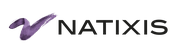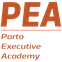</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Why objects? |
| 2 | You already use objects every day |
| 3 | Class and object — blueprint and thing |
| 4 | `__init__`, attributes, and `self` |
| 5 | Methods — giving an object something to do |
| 6 | Shared data, and keeping the inside inside |
| 7 | Inheritance — building on a class you already have |
| 8 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Explain what an object is, and recognise one when you read code
- Write a class with its own data and its own behaviour
- Keep an object's internal workings out of everyone else's way
- Read and write `class Something(SomethingElse):`

---

> 💡 In Class 1 you gave payments somewhere to **live**. Today you give them somewhere to
> **belong**: one thing that holds a payment's details *and* the things you do to it.

---
## 1. Why objects?

By now you can write a program as variables plus functions. That works, and for a script it is
often the right answer. It starts to hurt when several things belong together:

```
reference   = "PAY-001"
supplier    = "Alpha Supplies"
amount      = 1250.00
status      = "pending"
```

Four loose variables, and nothing says they are one payment. Now handle a second payment and
you need `reference2`, `amount2`… and every function needs all four passed in, in the right
order.

An **object** is one thing that holds:

| | Called | Example |
|---|--------|---------|
| its **data** | attributes | the reference, the supplier, the amount |
| its **behaviour** | methods | work out the total, mark it paid |

So instead of four variables and a function taking four arguments, you have one `payment` that
knows its own details and what can be done to it. Ten payments are a list of ten objects, and
each one carries its own data with it.

> 💡 You are not obliged to use classes. A short script is usually clearer without them. Reach
> for a class when you notice yourself passing the same three or four values into every
> function — that is the signal.

---
## 2. You already use objects every day

Every value in Python is an object. A string, a list, a DataFrame — each one carries its own
data **and** its own methods, which is exactly the definition above.

- `type(x)` tells you what **kind** of object `x` is — its **class**
- `x.upper()` calls a **method** that belongs to that object
- `x.upper` without brackets is the method itself, not its result

You have been doing this since Level 1 Class 1. `"hello".upper()` is a method call on a `str`
object. `my_list.append(3)` is a method call on a `list` object. Today you build your own.

In [ ]:
text = "hello"
print(type(text))            # <class 'str'>  - text is a str object
print(text.upper())          # a method belonging to that object

numbers = [3, 1, 2]
print(type(numbers))         # <class 'list'>
numbers.append(4)            # a method belonging to this list, changing this list
numbers.sort()
print(numbers)

# Two objects of the same class, each with its own data
other = [9, 8]
other.append(7)
print(numbers, other)        # appending to one did nothing to the other

---
## 3. Class and object — blueprint and thing

| Word | What it is | Analogy |
|------|-----------|---------|
| **Class** | The description: what every one of these has and can do | the blueprint of a house |
| **Object** | One actual thing built from it, with its own data | a house built from that blueprint |

One class, as many objects as you like — and each keeps its **own** values:

```
        class Payment          the blueprint, written once
              │
    ┌─────────┼─────────┐
    ▼         ▼         ▼
 PAY-001   PAY-002   PAY-003    each with its own data
```

Making an object from a class is called **creating an instance**, and you do it by calling the
class like a function: `Payment("PAY-001", "Alpha Supplies", 1250.00)`.

The convention: class names are written in `CapitalCase`, so `Payment`, not `payment`. That is
how you spot a class in someone else's code.

### The whole idea in one picture

<div style="background:#FFFFFF; color:#1D1D1B; display:inline-block; padding:8px; border-radius:8px;">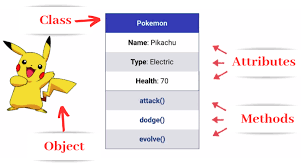</div>

**Pokemon** is the class — the description of what every Pokémon has and can do. **Pikachu** is
an object: one actual Pokémon built from it. Its **attributes** are the data it carries
(a name, a type, a health value) and its **methods** are the things it can do (attack, dodge,
evolve).

Everything in the next three sections is in that picture. A `Payment` class instead of
`Pokemon`; a reference, supplier and amount instead of name, type and health; `total()` and
`mark_paid()` instead of `attack()` and `dodge()`. Same shape.

---
## 4. `__init__`, attributes, and `self`

```
class Payment:
    def __init__(self, reference, supplier, amount):
        self.reference = reference
```

Three new things, and they always appear together:

| Piece | What it is |
|-------|-----------|
| `__init__` | a **method that runs automatically** when you create an object. Its job is to set up the starting data |
| `self` | **this particular object** — the one being worked on right now |
| `self.reference = reference` | store a value **on the object**, where it stays |

`self` is the part that looks strange. Read it as *"my own"*: `self.amount` means *this
payment's amount*, as opposed to any other payment's. Every method takes `self` as its first
parameter, and **Python passes it for you** — you never write it at the call.

> ⚠️ `self.amount = amount` and `amount = amount` are completely different. The first stores the
> value **on the object**, so it is still there later. The second makes a local variable that
> vanishes when `__init__` ends — a mistake that produces an object with nothing in it.

In [ ]:
class Payment:
    def __init__(self, reference, supplier, amount):
        self.reference = reference      # store it ON this object
        self.supplier = supplier
        self.amount = amount


# Creating objects - __init__ runs automatically each time
first = Payment("PAY-001", "Alpha Supplies", 1250.00)
second = Payment("PAY-002", "Delta Services", 480.50)

print(first.reference, first.supplier, first.amount)
print(second.reference, second.supplier, second.amount)
print(type(first))              # <class '__main__.Payment'>

# Each object keeps its own data
first.amount = 1300.00
print(first.amount, second.amount)   # changing one left the other alone

---
## 5. Methods — giving an object something to do

A **method** is just a function written inside a class. It takes `self` first, which is how it
can reach the object's own attributes.

The gain over a plain function: the method already knows the data. Compare

```
total_of(payment_reference, payment_amount, payment_rate)      a function
payment.total()                                                a method
```

The second cannot be called with the wrong payment's amount by mistake, because there is only
one payment involved.

In [ ]:
class Payment:
    def __init__(self, reference, supplier, amount):
        self.reference = reference
        self.supplier = supplier
        self.amount = amount
        self.status = "pending"

    def total(self):
        """The amount owed, in EUR."""
        return round(self.amount, 2)

    def mark_paid(self):
        """Record that this payment has gone out."""
        self.status = "paid"

    def describe(self):
        """One line describing this payment."""
        return f"{self.reference}  {self.supplier:<16}{self.total():>9.2f}  {self.status}"


payment = Payment("PAY-001", "Alpha Supplies", 1250.00)
print(payment.describe())

payment.mark_paid()              # no arguments - it works on its own data
print(payment.describe())

---
## 6. Shared data, and keeping the inside inside

### Data that belongs to every object

An attribute set with `self.` in `__init__` is **per object** — each payment has its own. An
attribute written straight in the class body is **shared by all of them**:

```
class Payment:
    approval_limit = 1000.00        one value, shared by every payment
```

Use it for things that are true of the whole class rather than one instance: a limit, a rate, a
label. Change it in one place and every object sees the new value.

### Keeping the inside inside — encapsulation

**Encapsulation** means: keep an object's data and the methods that manage it together, and
hide the messy details behind a simple front door.

Python has no truly private data, but there is a strong convention: a name starting with an
underscore — `self._log` — means *"internal, please don't touch this from outside"*. Other code
should go through methods instead.

The payoff is freedom to change your mind. If nobody outside ever touches `self._log`, you can
switch it from a list to a database later and no other code breaks.

> 📖 **Good to know:** `@property` lets a method be read like an attribute —
> `payment.total` rather than `payment.total()`. You will see it in other people's code. You do
> not need it today, and no exercise asks for it.

In [ ]:
class Payment:
    approval_limit = 1000.00          # shared by EVERY payment

    def __init__(self, reference, amount):
        self.reference = reference    # this payment's own
        self.amount = amount
        self._log = []                # internal - note the underscore

    def needs_approval(self):
        """True when this payment is above the shared limit."""
        return self.amount > Payment.approval_limit

    def mark_paid(self):
        """Record the payment, keeping a note of what happened."""
        self._log.append(f"{self.reference} paid")

    def history(self):
        """A clean way to read the log from outside."""
        return list(self._log)


big = Payment("PAY-001", 1250.00)
small = Payment("PAY-004", 95.20)

print(big.needs_approval(), small.needs_approval())
print(big.approval_limit, small.approval_limit)     # the same shared value

big.mark_paid()
print(big.history())        # we read it through a method, not by touching _log

---
## 7. Inheritance — building on a class you already have

Some payments go abroad, so they carry an exchange rate and their total is worked out
differently. Everything *else* about them is identical to a normal payment.

**Inheritance** lets a new class start from an existing one and change only what differs:

```
   class Payment               reference, amount
     │                         total(), describe()
     │
     └── class ForeignPayment  adds a rate
                               changes total()
                               keeps everything else
```

| Piece | Means |
|-------|-------|
| `class ForeignPayment(Payment):` | start from `Payment` — the **parent** in brackets |
| `super().__init__(...)` | run the parent's set-up, so you don't repeat it |
| Defining `total()` again | **overriding** — this class's version wins |
| Everything not mentioned | inherited unchanged, for free |

`isinstance(x, Payment)` is `True` for a `ForeignPayment` too — it *is* a payment, just a more
specific one. That is the test for whether inheritance is the right tool.

> ⚠️ **When not to use it.** Inheritance is for *"this is a kind of that"*. If two classes
> merely happen to share some code, that is not inheritance — that is two functions. Reaching
> for inheritance to avoid retyping is the most common way object-oriented code goes wrong.

> 💡 You will **read** this far more often than you write it. Every library you use is built
> this way, so `class Something(SomethingElse):` needs to be a sentence you understand at a
> glance, even if you rarely write one yourself.

In [ ]:
class Payment:
    def __init__(self, reference, amount):
        self.reference = reference
        self.amount = amount

    def total(self):
        """The amount owed, in EUR."""
        return round(self.amount, 2)

    def describe(self):
        """One line describing this payment."""
        return f"{self.reference}  {self.total():>9.2f} EUR"


class ForeignPayment(Payment):                       # starts from Payment
    def __init__(self, reference, amount, rate):
        super().__init__(reference, amount)          # let Payment do its own set-up
        self.rate = rate                             # then add what is new

    def total(self):                                 # overriding: this version wins
        """The amount converted into EUR."""
        return round(self.amount * self.rate, 2)


home = Payment("PAY-001", 1250.00)
abroad = ForeignPayment("PAY-003", 2400.00, 0.92)

print(home.total(), abroad.total())
print(abroad.describe())          # inherited from Payment, and it works
print(isinstance(abroad, Payment))   # True - a ForeignPayment IS a Payment

In [ ]:
# The real gain: one loop, and each object does the right thing for itself
payments = [
    Payment("PAY-001", 1250.00),
    ForeignPayment("PAY-003", 2400.00, 0.92),
    Payment("PAY-004", 95.20),
    ForeignPayment("PAY-006", 640.00, 1.17),
]

for payment in payments:
    print(payment.describe())     # describe() is written once, in Payment

print()
print("Total:", round(sum([payment.total() for payment in payments]), 2))

---
## 8. 🔗 Putting it all together — a payments file

Everything from today, as one small, complete piece of code.

### The situation

The same payments as Class 1, but now each one is an **object** rather than a row. A payment
knows its own details, can say what it is worth, can be marked as paid, and keeps a note of what
happened to it. Foreign payments behave the same way but convert their amount first.

### What the program must do

1. A `Payment` class with a **shared approval limit**, its own reference, supplier and amount,
   and an **internal** log
2. Methods to give the total, say whether it needs approval, mark it paid, and describe itself
3. A `ForeignPayment` that inherits all of it, **adds** a rate, and **overrides** the total
4. Build a list of both kinds, and run one loop over them
5. Print a report: each payment, then the total, and which ones need approval

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| `class`, `__init__`, `self` | both classes |
| Attributes | `reference`, `supplier`, `amount`, `rate` |
| Methods | `total`, `needs_approval`, `mark_paid`, `describe` |
| Class variable | `approval_limit`, shared by every payment |
| Encapsulation | `_log`, read only through `history()` |
| Inheritance | `ForeignPayment(Payment)` |
| `super().__init__()` | reusing the parent's set-up |
| Overriding | `total()` in `ForeignPayment` |
| One loop, mixed types | the report |
| `sum`, f-strings, `for`, `if` | from Levels 1 and 2 |

In [ ]:
class Payment:
    """A payment to a supplier, in EUR."""

    approval_limit = 1000.00                      # shared by every payment

    def __init__(self, reference, supplier, amount):
        self.reference = reference
        self.supplier = supplier
        self.amount = amount
        self._log = []                            # internal

    def total(self):
        """What this payment is worth, in EUR."""
        return round(self.amount, 2)

    def needs_approval(self):
        """True when the total is above the shared limit."""
        return self.total() > Payment.approval_limit

    def mark_paid(self):
        """Record that it has gone out."""
        self._log.append("paid")

    def history(self):
        """Read the internal log from outside."""
        return list(self._log)

    def describe(self):
        """One line of the report."""
        line = f"{self.reference}  {self.supplier:<16}{self.total():>9.2f}"
        if self.needs_approval():
            line = line + "  APPROVAL"
        return line


class ForeignPayment(Payment):
    """A payment made in another currency, converted into EUR."""

    def __init__(self, reference, supplier, amount, rate):
        super().__init__(reference, supplier, amount)
        self.rate = rate

    def total(self):
        """The amount converted into EUR."""
        return round(self.amount * self.rate, 2)

In [ ]:
# Nothing has run yet - the cell above only described two kinds of payment.
payments = [
    Payment("PAY-001", "Alpha Supplies", 1250.00),
    Payment("PAY-004", "Kestrel Print", 95.20),
    ForeignPayment("PAY-003", "Alpha Supplies", 2400.00, 0.92),
    ForeignPayment("PAY-006", "Northwind Ltd", 640.00, 1.17),
]

print("PAYMENTS")
print("-" * 52)
for payment in payments:
    print(payment.describe())            # each object does the right thing for itself

payments[0].mark_paid()

print("-" * 52)
print(f"Payments        : {len(payments)}")
totals = [payment.total() for payment in payments]
print(f"Total           : {round(sum(totals), 2):,.2f} EUR")
needing = [payment for payment in payments if payment.needs_approval()]
print(f"Needing approval: {len(needing)}")
print(f"History of first: {payments[0].history()}")

---

### 🎉 That's Level 3 Class 2!

| Concept | Key syntax |
|---------|-----------|
| Define a class | `class Payment:` — `CapitalCase` |
| Set-up method | `def __init__(self, ...):` |
| This object | `self` |
| Store data on it | `self.amount = amount` |
| Create an object | `Payment("PAY-001", 1250.00)` |
| Method | `def total(self):` — called as `payment.total()` |
| Shared by all objects | a name in the class body: `approval_limit = 1000.00` |
| Internal, hands off | `self._log` — read it through a method |
| Inherit | `class ForeignPayment(Payment):` |
| Reuse the parent's set-up | `super().__init__(...)` |
| Override | define the method again in the child |
| Is it one of those? | `isinstance(x, Payment)` |

> 💡 **The word you now know:** when different objects answer the same call in their own way —
> `describe()` giving the right line for both kinds of payment — that is called
> **polymorphism**. You have been using it all class; now you have the name for it.

> 💡 **And the honest advice:** most of the Python you write will not need classes, and a short
> script is usually clearer without them. What this class buys you is the ability to *read* the
> code that does — which is most libraries, and most of what you will find when you search for
> an answer.

➡️ Now open the **exercises notebook**.